# Импорты и константы

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')

# DATASET: FINAL

## Загрузка данных

In [3]:
df_tr = pd.read_csv('../data/processed/train_final.csv')
df_te = pd.read_csv('../data/processed/test_final.csv')

"\ndf_tr = pd.read_csv('../data/processed/train_final.csv')\ndf_te = pd.read_csv('../data/processed/test_final.csv')\n"

In [5]:
SEED = 42
N_SPLITS = 5
TARGETS = ['sqrt_IC50, mM', 'sqrt_CC50, mM', 'sqrt_SI']
TARGETS_ORIG = ['IC50, mM', 'CC50, mM', 'SI']

def custom_rmse(y_true_ic, y_true_cc, y_true_si, y_pred_ic, y_pred_cc, y_pred_si):
    rmse_ic = np.sqrt(np.mean((y_true_ic - y_pred_ic)**2))
    rmse_cc = np.sqrt(np.mean((y_true_cc - y_pred_cc)**2))
    rmse_si = np.sqrt(np.mean((y_true_si - y_pred_si)**2))
    return (rmse_ic + rmse_cc + rmse_si) / 3.0

In [6]:
drop_cols = TARGETS + TARGETS_ORIG + ['index']
feat_names = [c for c in df_tr.columns if c not in drop_cols]

X_tr = df_tr[feat_names].values
Y_tr = df_tr[TARGETS].values
Y_orig = df_tr[TARGETS_ORIG].values
X_te = df_te[feat_names].values

## Подбор весов для 4 ансамблей

In [7]:
weight_grid = [0.3, 0.4, 0.5, 0.6, 0.7]
kf3 = KFold(n_splits=3, shuffle=True, random_state=SEED)

ensemble_configs = [
    ('CB_XGB',
     lambda: CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05, verbose=0, random_seed=SEED),
     lambda: XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, verbosity=0, random_state=SEED)),
    ('LGB_XGB',
     lambda: LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, verbose=-1, random_state=SEED),
     lambda: XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, verbosity=0, random_state=SEED)),
    ('CB_LGB',
     lambda: CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05, verbose=0, random_seed=SEED),
     lambda: LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, verbose=-1, random_state=SEED)),
    ('CB_LGB_XGB',
     lambda: CatBoostRegressor(iterations=500, depth=6, learning_rate=0.05, verbose=0, random_seed=SEED),
     lambda: LGBMRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, verbose=-1, random_state=SEED),
     lambda: XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, verbosity=0, random_state=SEED)),
]

In [8]:
best_configs = {}

for config in ensemble_configs:
    name = config[0]
    models_fns = config[1:]
    n_models = len(models_fns)
    best_rmse = float('inf')
    best_weights = None

    if n_models == 2:
        for w1 in weight_grid:
            scr = []
            for ti, vi in kf3.split(X_tr):
                preds = np.zeros((len(vi), 3))
                for t_idx in range(3):
                    m_list = [fn().fit(X_tr[ti], Y_tr[ti, t_idx]) for fn in models_fns]
                    preds[:, t_idx] = w1 * m_list[0].predict(X_tr[vi]) + (1 - w1) * m_list[1].predict(X_tr[vi])
                scr.append(custom_rmse(
                    Y_orig[vi, 0], Y_orig[vi, 1], Y_orig[vi, 2],
                    np.clip(preds[:, 0], 0, None)**2,
                    np.clip(preds[:, 1], 0, None)**2,
                    np.clip(preds[:, 2], 0, None)**2
                ))
            mu = np.mean(scr)
            if mu < best_rmse:
                best_rmse, best_weights = mu, [w1, 1 - w1]
            print(f"  {name}  w={w1:.1f}/{1-w1:.1f}  CV RMSE={mu:.2f}")

    else:  # 3 модели перебор двух весов, третий = остаток
        for w1 in [0.3, 0.4, 0.5]:
            for w2 in [0.2, 0.25, 0.3]:
                if w1 + w2 >= 1.0:
                    continue
                w3 = 1.0 - w1 - w2
                scr = []
                for ti, vi in kf3.split(X_tr):
                    preds = np.zeros((len(vi), 3))
                    for t_idx in range(3):
                        m_list = [fn().fit(X_tr[ti], Y_tr[ti, t_idx]) for fn in models_fns]
                        preds[:, t_idx] = (w1 * m_list[0].predict(X_tr[vi]) +
                                          w2 * m_list[1].predict(X_tr[vi]) +
                                          w3 * m_list[2].predict(X_tr[vi]))
                    scr.append(custom_rmse(
                        Y_orig[vi, 0], Y_orig[vi, 1], Y_orig[vi, 2],
                        np.clip(preds[:, 0], 0, None)**2,
                        np.clip(preds[:, 1], 0, None)**2,
                        np.clip(preds[:, 2], 0, None)**2
                    ))
                mu = np.mean(scr)
                if mu < best_rmse:
                    best_rmse, best_weights = mu, [w1, w2, w3]
                print(f"  {name}  w={w1:.2f}/{w2:.2f}/{w3:.2f}  CV RMSE={mu:.2f}")

    best_configs[name] = (best_weights, best_rmse)
    print(f" {name} best weights: {best_weights}  RMSE={best_rmse:.2f}\n")

  CB_XGB  w=0.3/0.7  CV RMSE=317.13
  CB_XGB  w=0.4/0.6  CV RMSE=315.60
  CB_XGB  w=0.5/0.5  CV RMSE=314.32
  CB_XGB  w=0.6/0.4  CV RMSE=313.27
  CB_XGB  w=0.7/0.3  CV RMSE=312.45
 CB_XGB best weights: [0.7, 0.30000000000000004]  RMSE=312.45

  LGB_XGB  w=0.3/0.7  CV RMSE=318.47
  LGB_XGB  w=0.4/0.6  CV RMSE=317.30
  LGB_XGB  w=0.5/0.5  CV RMSE=316.33
  LGB_XGB  w=0.6/0.4  CV RMSE=315.56
  LGB_XGB  w=0.7/0.3  CV RMSE=315.01
 LGB_XGB best weights: [0.7, 0.30000000000000004]  RMSE=315.01

  CB_LGB  w=0.3/0.7  CV RMSE=311.87
  CB_LGB  w=0.4/0.6  CV RMSE=311.31
  CB_LGB  w=0.5/0.5  CV RMSE=310.92
  CB_LGB  w=0.6/0.4  CV RMSE=310.70
  CB_LGB  w=0.7/0.3  CV RMSE=310.63
 CB_LGB best weights: [0.7, 0.30000000000000004]  RMSE=310.63

  CB_LGB_XGB  w=0.30/0.20/0.50  CV RMSE=314.61
  CB_LGB_XGB  w=0.30/0.25/0.45  CV RMSE=314.10
  CB_LGB_XGB  w=0.30/0.30/0.40  CV RMSE=313.65
  CB_LGB_XGB  w=0.40/0.20/0.40  CV RMSE=313.36
  CB_LGB_XGB  w=0.40/0.25/0.35  CV RMSE=312.92
  CB_LGB_XGB  w=0.40/0.30/0.30

## Кросс-валидация с лучшими весами и сохранение результата для Kaggle

In [9]:
for config in ensemble_configs:
    name = config[0]
    models_fns = config[1:]
    weights = best_configs[name][0]

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    OOF = np.zeros_like(Y_tr)
    TEST = np.zeros((len(X_te), 3))
    fold_err = []

    for ti, vi in kf.split(X_tr):
        f_val = np.zeros((len(vi), 3))
        f_tes = np.zeros((len(X_te), 3))
        for t_idx in range(3):
            m_list = [fn().fit(X_tr[ti], Y_tr[ti, t_idx]) for fn in models_fns]
            f_val[:, t_idx] = sum(w * m.predict(X_tr[vi]) for w, m in zip(weights, m_list))
            f_tes[:, t_idx] = sum(w * m.predict(X_te) for w, m in zip(weights, m_list))
        OOF[vi] = f_val
        TEST += f_tes / N_SPLITS
        fold_err.append(custom_rmse(
            Y_orig[vi, 0], Y_orig[vi, 1], Y_orig[vi, 2],
            np.clip(f_val[:, 0], 0, None)**2,
            np.clip(f_val[:, 1], 0, None)**2,
            np.clip(f_val[:, 2], 0, None)**2
        ))

    print(f"{name} OOF RMSE: {np.mean(fold_err):.2f} +/- {np.std(fold_err):.2f}")

    sub = pd.DataFrame({
        'index': np.arange(len(TEST)),
        'IC50': np.clip(TEST[:, 0], 0, None)**2,
        'CC50': np.clip(TEST[:, 1], 0, None)**2,
        'SI': np.clip(TEST[:, 2], 0, None)**2
    })
    sub.to_csv(f'ensemble_{name.lower()}_datafinal_submission.csv', index=False)

CB_XGB OOF RMSE: 305.48 +/- 32.79
LGB_XGB OOF RMSE: 309.09 +/- 34.34
CB_LGB OOF RMSE: 303.13 +/- 31.16
CB_LGB_XGB OOF RMSE: 304.85 +/- 32.59


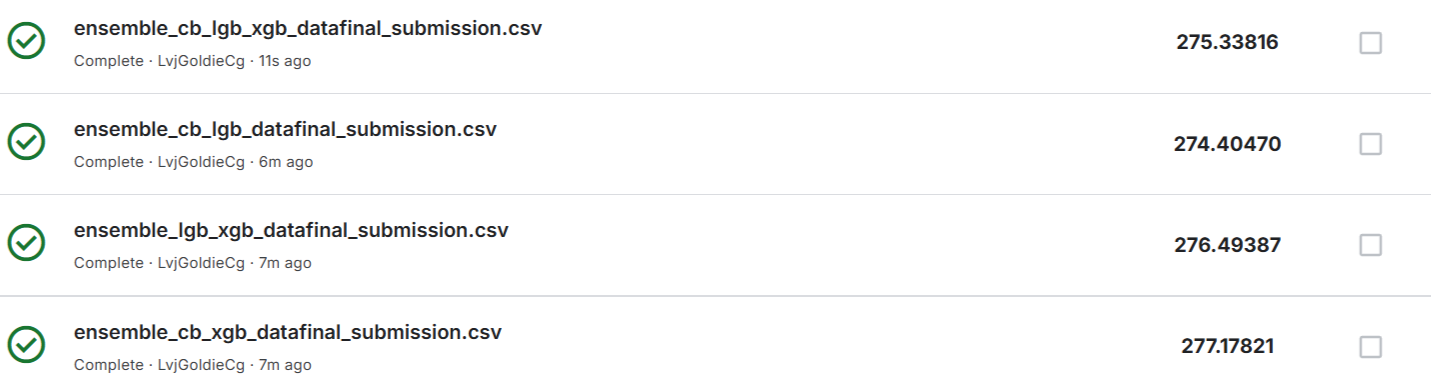

## Графики Actual vs Predicted

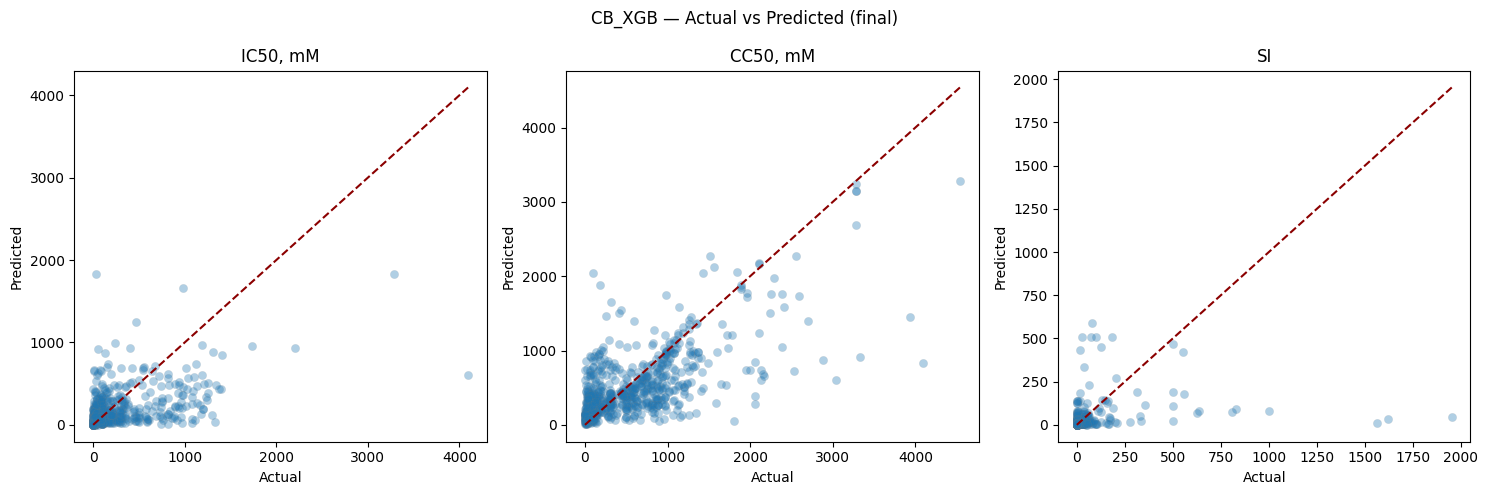

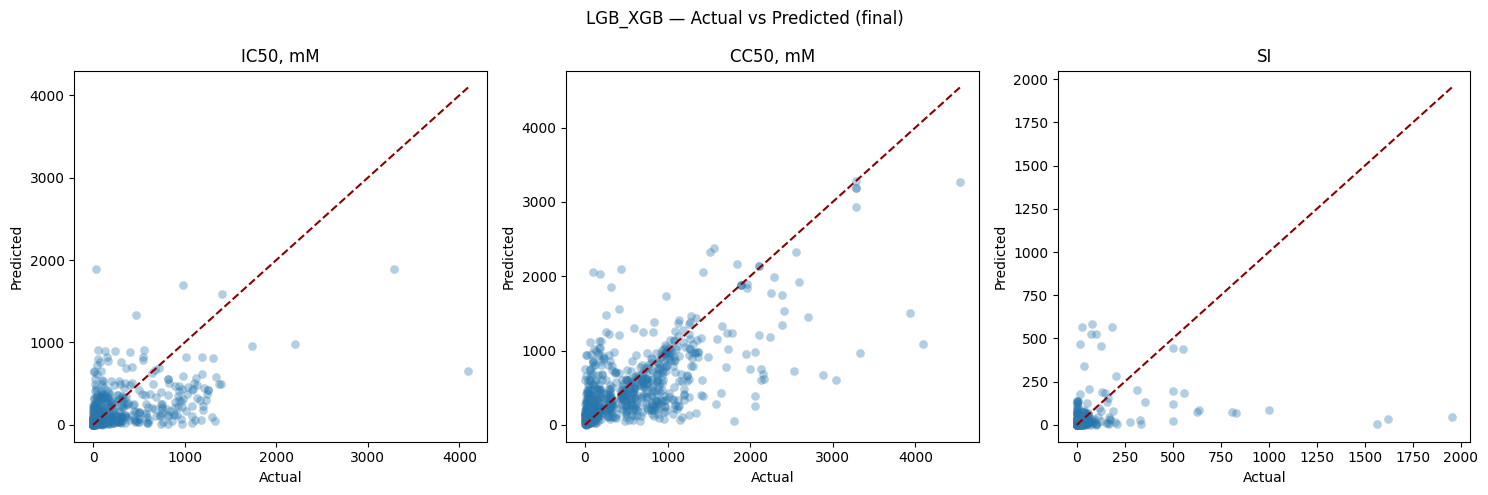

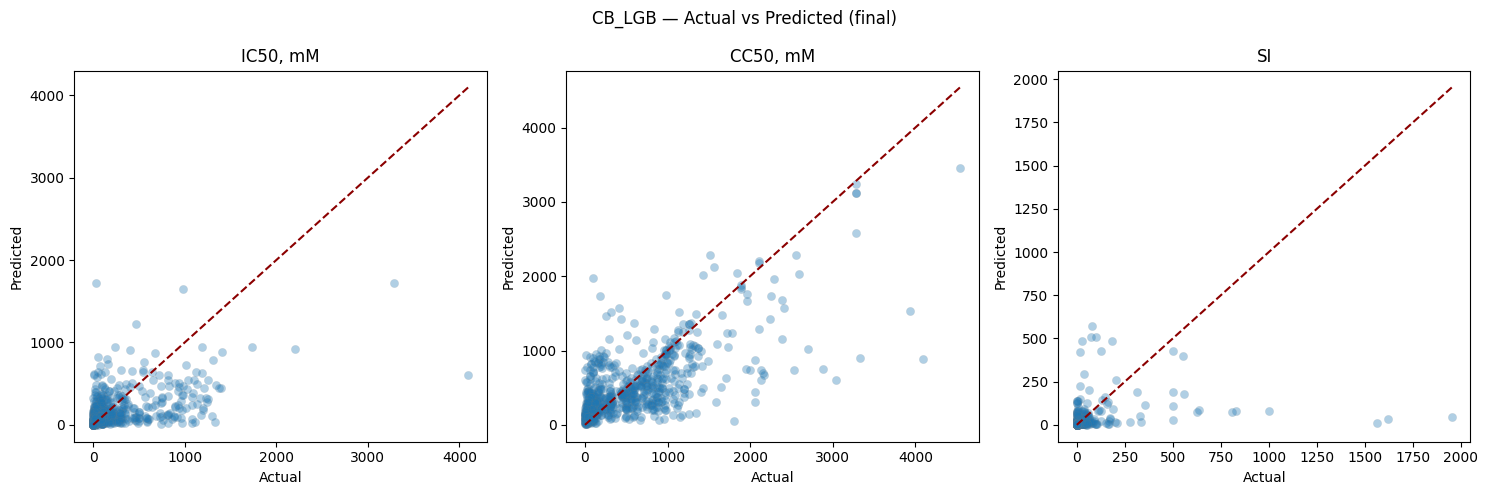

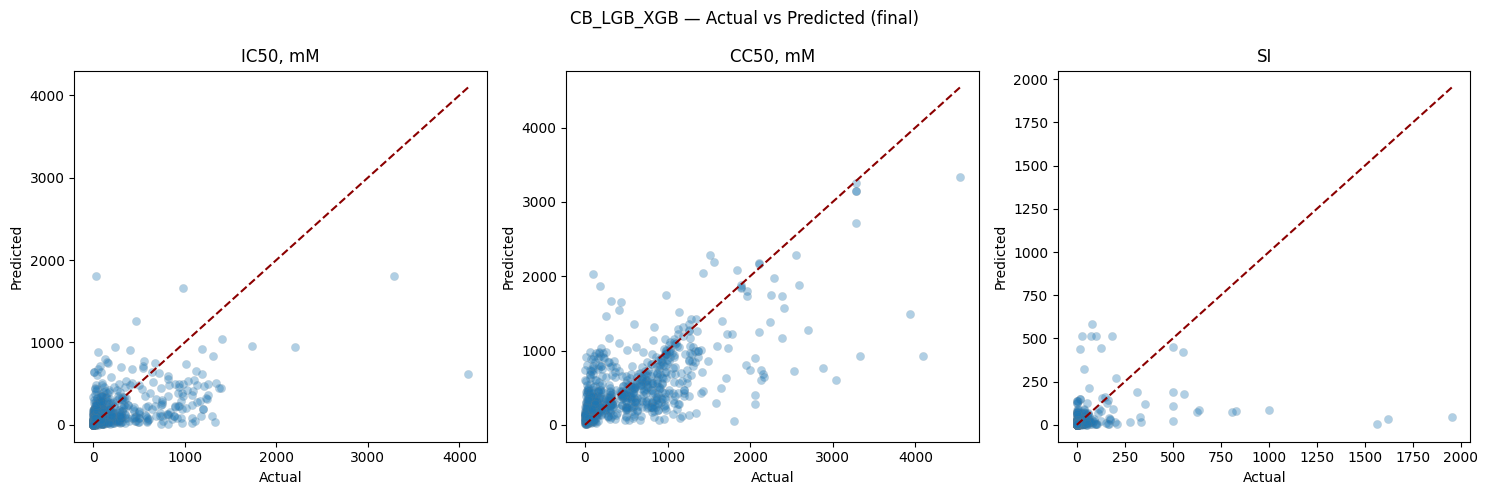

In [10]:
for config in ensemble_configs:
    name = config[0]
    models_fns = config[1:]
    weights = best_configs[name][0]

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    OOF = np.zeros_like(Y_tr)

    for ti, vi in kf.split(X_tr):
        f_val = np.zeros((len(vi), 3))
        for t_idx in range(3):
            m_list = [fn().fit(X_tr[ti], Y_tr[ti, t_idx]) for fn in models_fns]
            f_val[:, t_idx] = sum(w * m.predict(X_tr[vi]) for w, m in zip(weights, m_list))
        OOF[vi] = f_val

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for j, target_name in enumerate(TARGETS_ORIG):
        pred = np.clip(OOF[:, j], 0, None)**2
        ax[j].scatter(Y_orig[:, j], pred, alpha=0.35, edgecolors='grey', linewidth=0.2)
        lo, hi = min(Y_orig[:, j].min(), 0), Y_orig[:, j].max()
        ax[j].plot([lo, hi], [lo, hi], '--', color='darkred')
        ax[j].set_xlabel('Actual')
        ax[j].set_ylabel('Predicted')
        ax[j].set_title(target_name)
    plt.suptitle(f'{name} — Actual vs Predicted (final)')
    plt.tight_layout()
    plt.show()

## График остатков

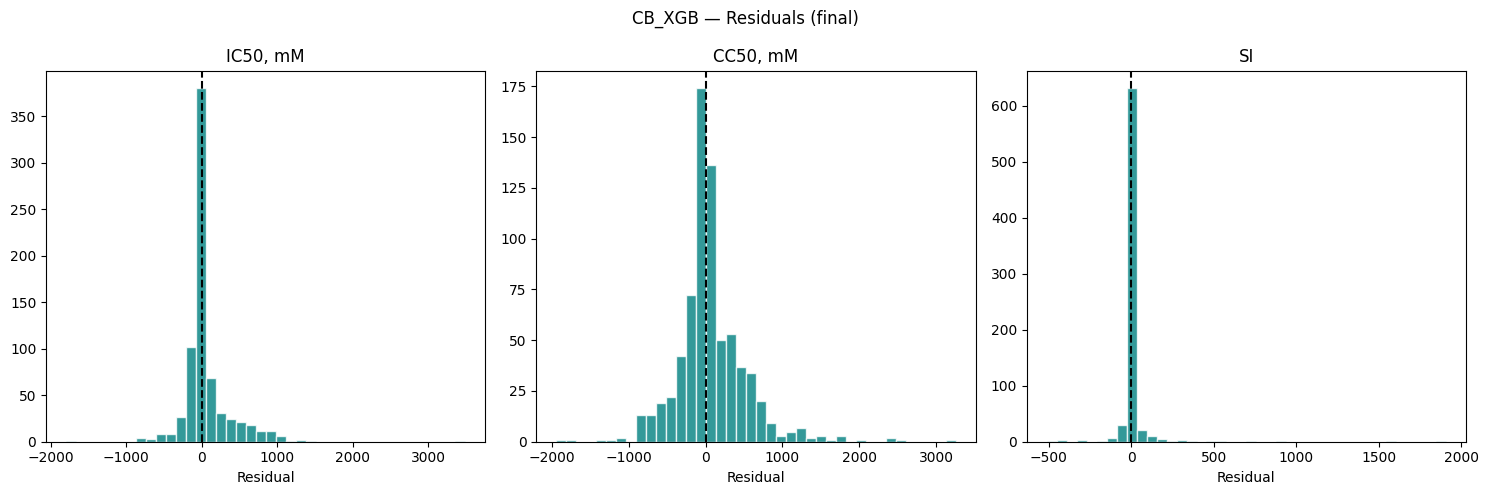

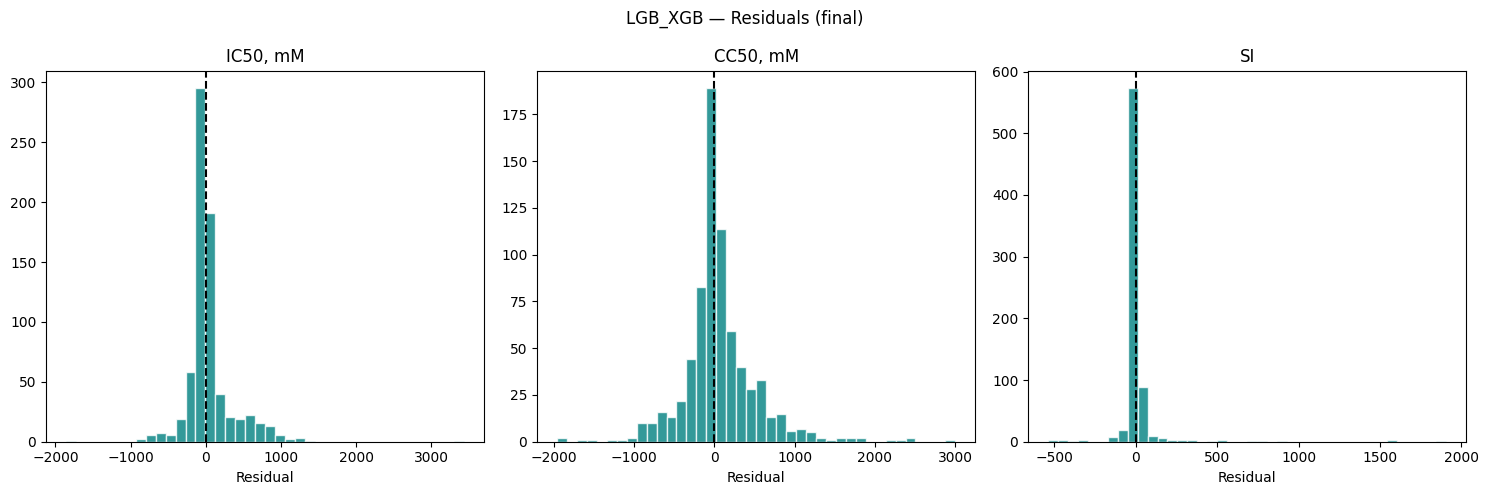

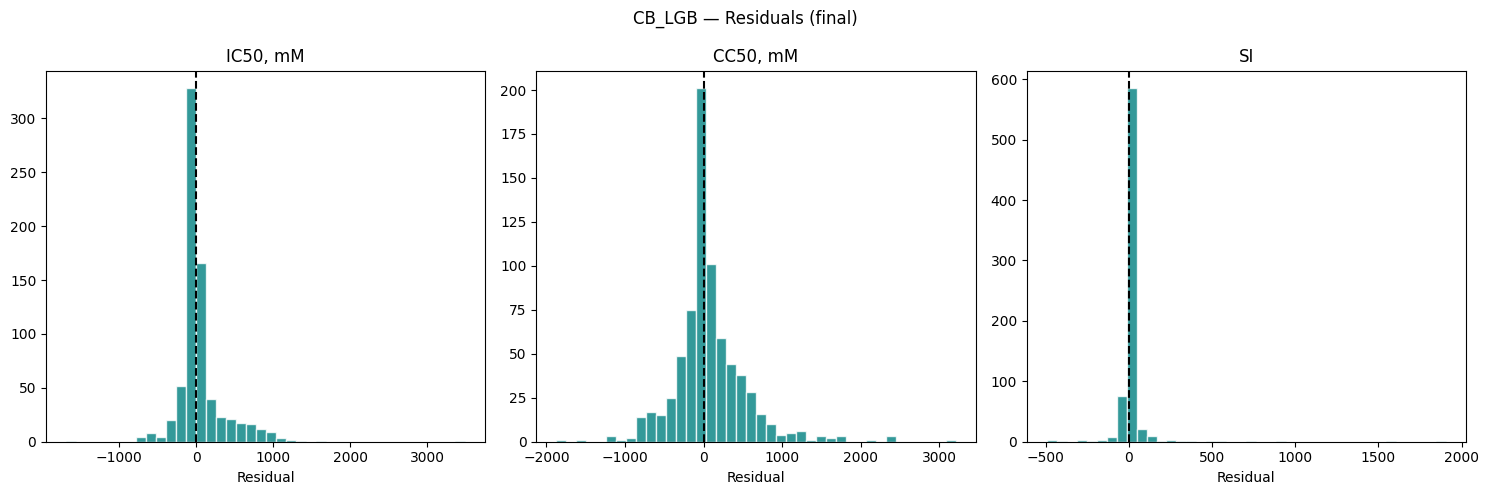

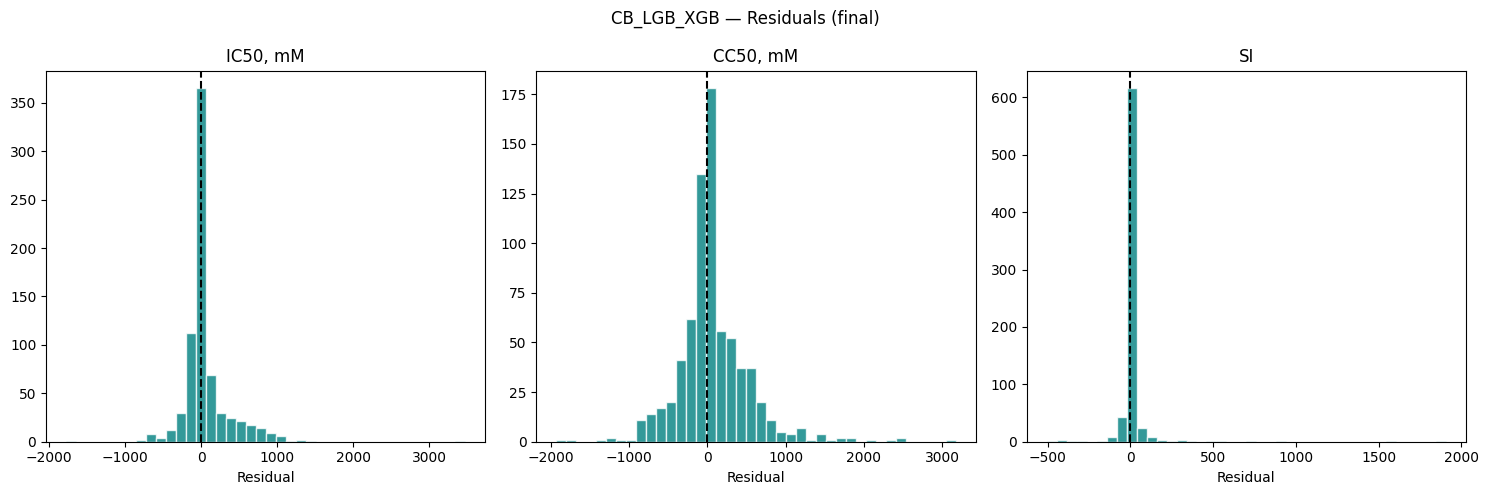

In [11]:
for config in ensemble_configs:
    name = config[0]
    models_fns = config[1:]
    weights = best_configs[name][0]

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    OOF = np.zeros_like(Y_tr)

    for ti, vi in kf.split(X_tr):
        f_val = np.zeros((len(vi), 3))
        for t_idx in range(3):
            m_list = [fn().fit(X_tr[ti], Y_tr[ti, t_idx]) for fn in models_fns]
            f_val[:, t_idx] = sum(w * m.predict(X_tr[vi]) for w, m in zip(weights, m_list))
        OOF[vi] = f_val

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for j, target_name in enumerate(TARGETS_ORIG):
        res = Y_orig[:, j] - np.clip(OOF[:, j], 0, None)**2
        ax[j].hist(res, bins=40, color='teal', edgecolor='white', alpha=0.8)
        ax[j].axvline(0, color='black', linestyle='--')
        ax[j].set_xlabel('Residual')
        ax[j].set_title(target_name)
    plt.suptitle(f'{name} — Residuals (final)')
    plt.tight_layout()
    plt.show()

# DATASET: ENGINEERED

## Загрузка данных

In [12]:
df_tr2 = pd.read_csv('../data/processed/train_with_engineered_features.csv')
df_te2 = pd.read_csv('../data/processed/test_with_engineered_features.csv')

"\ndf_tr2 = pd.read_csv('../data/processed/train_with_engineered_features.csv')\ndf_te2 = pd.read_csv('../data/processed/test_with_engineered_features.csv')\n"

In [14]:
drop_cols2 = TARGETS + TARGETS_ORIG + ['index']
feat_names2 = [c for c in df_tr2.columns if c not in drop_cols2]

X_tr2 = df_tr2[feat_names2].values
Y_tr2 = df_tr2[TARGETS].values
Y_orig2 = df_tr2[TARGETS_ORIG].values
X_te2 = df_te2[feat_names2].values

## Подбор весов (engineered)

In [15]:
best_configs2 = {}

for config in ensemble_configs:
    name = config[0]
    models_fns = config[1:]
    n_models = len(models_fns)
    best_rmse = float('inf')
    best_weights = None

    if n_models == 2:
        for w1 in weight_grid:
            scr = []
            for ti, vi in kf3.split(X_tr2):
                preds = np.zeros((len(vi), 3))
                for t_idx in range(3):
                    m_list = [fn().fit(X_tr2[ti], Y_tr2[ti, t_idx]) for fn in models_fns]
                    preds[:, t_idx] = w1 * m_list[0].predict(X_tr2[vi]) + (1 - w1) * m_list[1].predict(X_tr2[vi])
                scr.append(custom_rmse(
                    Y_orig2[vi, 0], Y_orig2[vi, 1], Y_orig2[vi, 2],
                    np.clip(preds[:, 0], 0, None)**2,
                    np.clip(preds[:, 1], 0, None)**2,
                    np.clip(preds[:, 2], 0, None)**2
                ))
            mu = np.mean(scr)
            if mu < best_rmse:
                best_rmse, best_weights = mu, [w1, 1 - w1]
            print(f"  {name}  w={w1:.1f}/{1-w1:.1f}  CV RMSE={mu:.2f}")

    else:
        for w1 in [0.3, 0.4, 0.5]:
            for w2 in [0.2, 0.25, 0.3]:
                if w1 + w2 >= 1.0:
                    continue
                w3 = 1.0 - w1 - w2
                scr = []
                for ti, vi in kf3.split(X_tr2):
                    preds = np.zeros((len(vi), 3))
                    for t_idx in range(3):
                        m_list = [fn().fit(X_tr2[ti], Y_tr2[ti, t_idx]) for fn in models_fns]
                        preds[:, t_idx] = (w1 * m_list[0].predict(X_tr2[vi]) +
                                          w2 * m_list[1].predict(X_tr2[vi]) +
                                          w3 * m_list[2].predict(X_tr2[vi]))
                    scr.append(custom_rmse(
                        Y_orig2[vi, 0], Y_orig2[vi, 1], Y_orig2[vi, 2],
                        np.clip(preds[:, 0], 0, None)**2,
                        np.clip(preds[:, 1], 0, None)**2,
                        np.clip(preds[:, 2], 0, None)**2
                    ))
                mu = np.mean(scr)
                if mu < best_rmse:
                    best_rmse, best_weights = mu, [w1, w2, w3]
                print(f"  {name}  w={w1:.2f}/{w2:.2f}/{w3:.2f}  CV RMSE={mu:.2f}")

    best_configs2[name] = (best_weights, best_rmse)
    print(f"{name} best weights: {best_weights}  RMSE={best_rmse:.2f}\n")

  CB_XGB  w=0.3/0.7  CV RMSE=317.95
  CB_XGB  w=0.4/0.6  CV RMSE=316.01
  CB_XGB  w=0.5/0.5  CV RMSE=314.33
  CB_XGB  w=0.6/0.4  CV RMSE=312.88
  CB_XGB  w=0.7/0.3  CV RMSE=311.68
CB_XGB best weights: [0.7, 0.30000000000000004]  RMSE=311.68

  LGB_XGB  w=0.3/0.7  CV RMSE=319.54
  LGB_XGB  w=0.4/0.6  CV RMSE=318.09
  LGB_XGB  w=0.5/0.5  CV RMSE=316.87
  LGB_XGB  w=0.6/0.4  CV RMSE=315.89
  LGB_XGB  w=0.7/0.3  CV RMSE=315.14
LGB_XGB best weights: [0.7, 0.30000000000000004]  RMSE=315.14

  CB_LGB  w=0.3/0.7  CV RMSE=310.95
  CB_LGB  w=0.4/0.6  CV RMSE=310.21
  CB_LGB  w=0.5/0.5  CV RMSE=309.66
  CB_LGB  w=0.6/0.4  CV RMSE=309.29
  CB_LGB  w=0.7/0.3  CV RMSE=309.09
CB_LGB best weights: [0.7, 0.30000000000000004]  RMSE=309.09

  CB_LGB_XGB  w=0.30/0.20/0.50  CV RMSE=314.80
  CB_LGB_XGB  w=0.30/0.25/0.45  CV RMSE=314.16
  CB_LGB_XGB  w=0.30/0.30/0.40  CV RMSE=313.57
  CB_LGB_XGB  w=0.40/0.20/0.40  CV RMSE=313.17
  CB_LGB_XGB  w=0.40/0.25/0.35  CV RMSE=312.60
  CB_LGB_XGB  w=0.40/0.30/0.30  C

## Кросс-валидация с лучшими весами и сохранение результата для Kaggle

In [16]:
for config in ensemble_configs:
    name = config[0]
    models_fns = config[1:]
    weights = best_configs2[name][0]

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    OOF2 = np.zeros_like(Y_tr2)
    TEST2 = np.zeros((len(X_te2), 3))
    fold_err2 = []

    for ti, vi in kf.split(X_tr2):
        f_val = np.zeros((len(vi), 3))
        f_tes = np.zeros((len(X_te2), 3))
        for t_idx in range(3):
            m_list = [fn().fit(X_tr2[ti], Y_tr2[ti, t_idx]) for fn in models_fns]
            f_val[:, t_idx] = sum(w * m.predict(X_tr2[vi]) for w, m in zip(weights, m_list))
            f_tes[:, t_idx] = sum(w * m.predict(X_te2) for w, m in zip(weights, m_list))
        OOF2[vi] = f_val
        TEST2 += f_tes / N_SPLITS
        fold_err2.append(custom_rmse(
            Y_orig2[vi, 0], Y_orig2[vi, 1], Y_orig2[vi, 2],
            np.clip(f_val[:, 0], 0, None)**2,
            np.clip(f_val[:, 1], 0, None)**2,
            np.clip(f_val[:, 2], 0, None)**2
        ))

    print(f"{name} OOF RMSE: {np.mean(fold_err2):.2f} +/- {np.std(fold_err2):.2f}")

    sub = pd.DataFrame({
        'index': np.arange(len(TEST2)),
        'IC50': np.clip(TEST2[:, 0], 0, None)**2,
        'CC50': np.clip(TEST2[:, 1], 0, None)**2,
        'SI': np.clip(TEST2[:, 2], 0, None)**2
    })
    sub.to_csv(f'ensemble_{name.lower()}_dataengineered_submission.csv', index=False)

CB_XGB OOF RMSE: 304.57 +/- 31.98
LGB_XGB OOF RMSE: 308.63 +/- 32.53
CB_LGB OOF RMSE: 303.51 +/- 30.30
CB_LGB_XGB OOF RMSE: 304.45 +/- 31.51


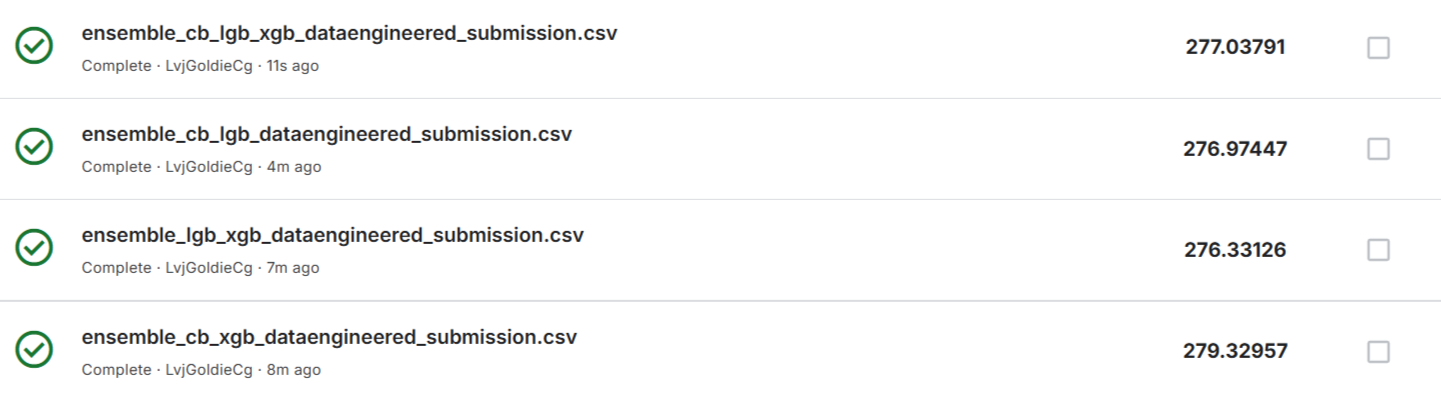

## График Actual vs Predicted (engineered)

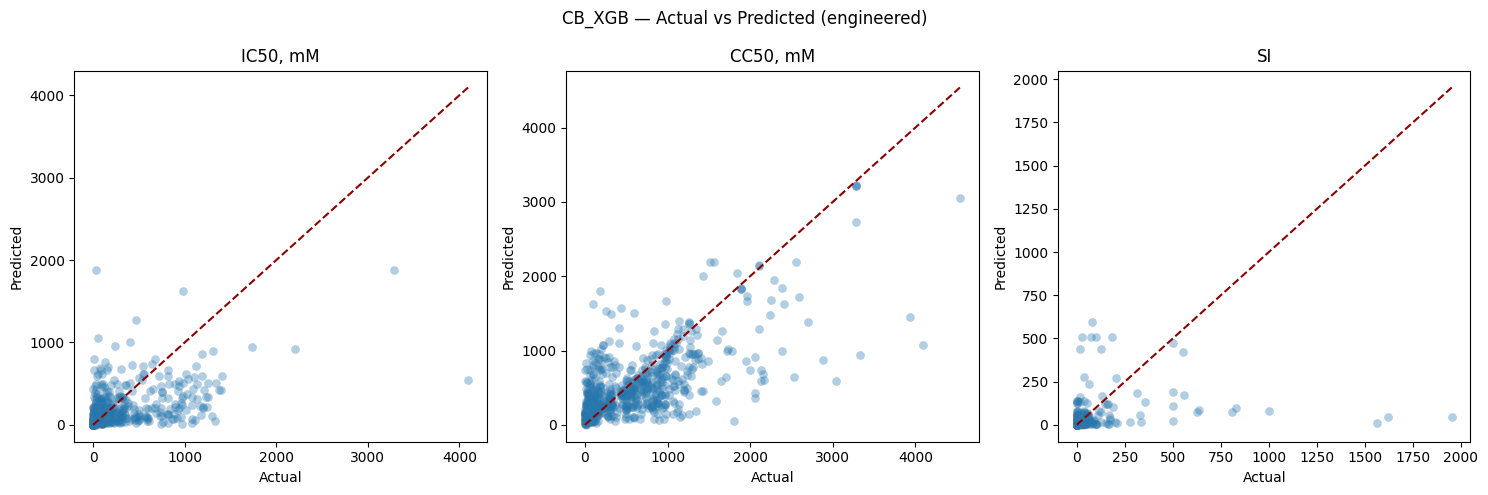

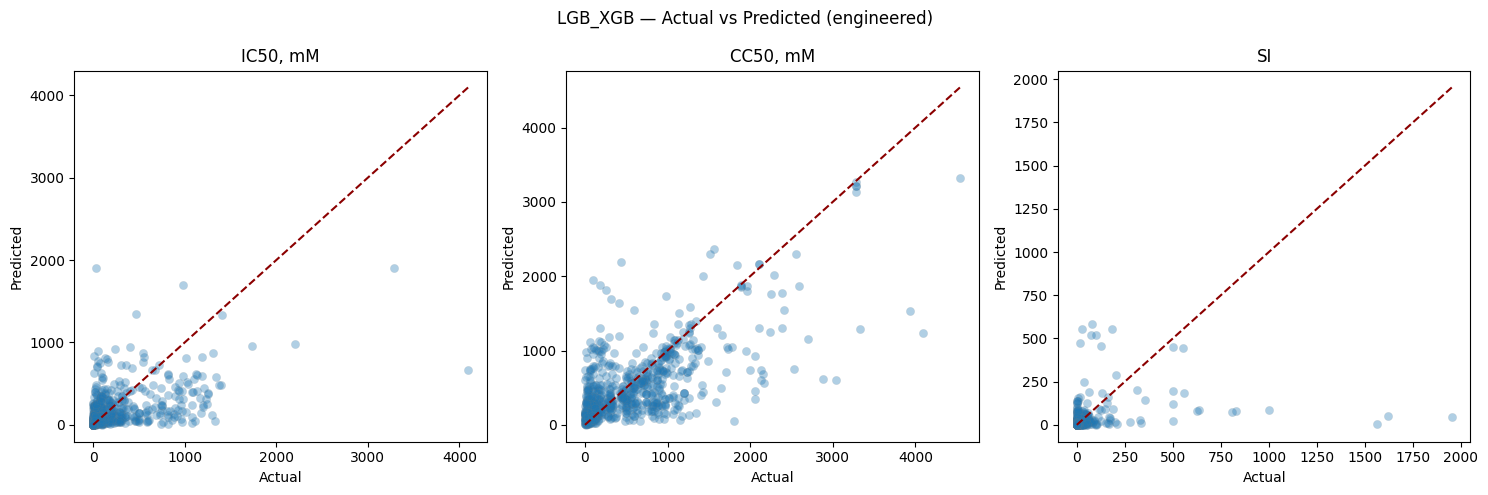

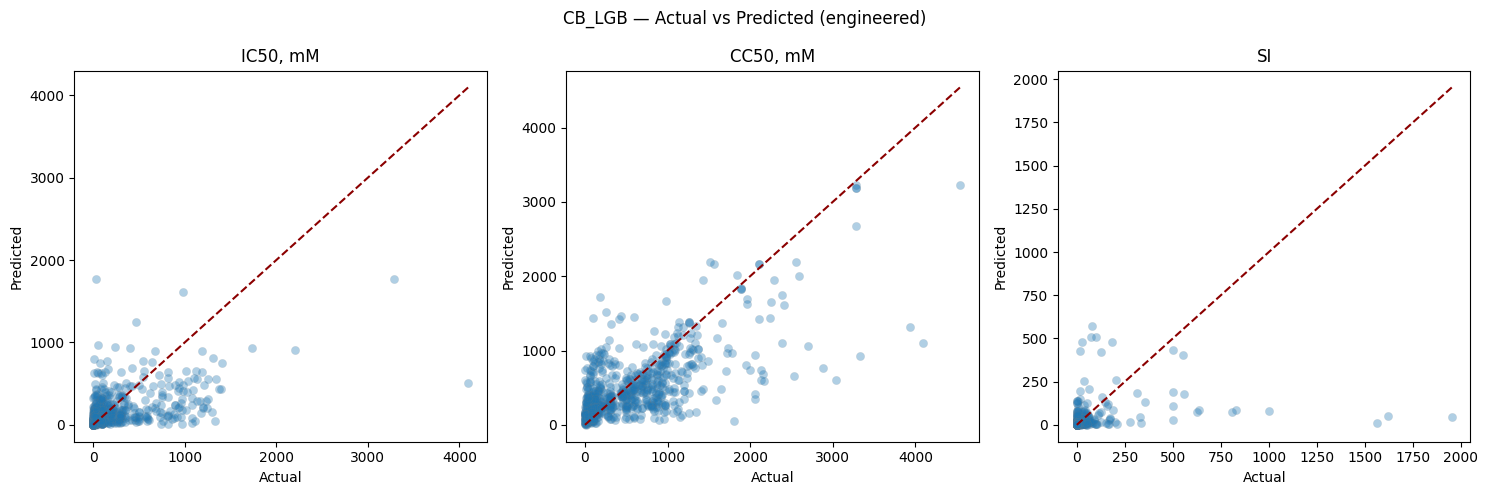

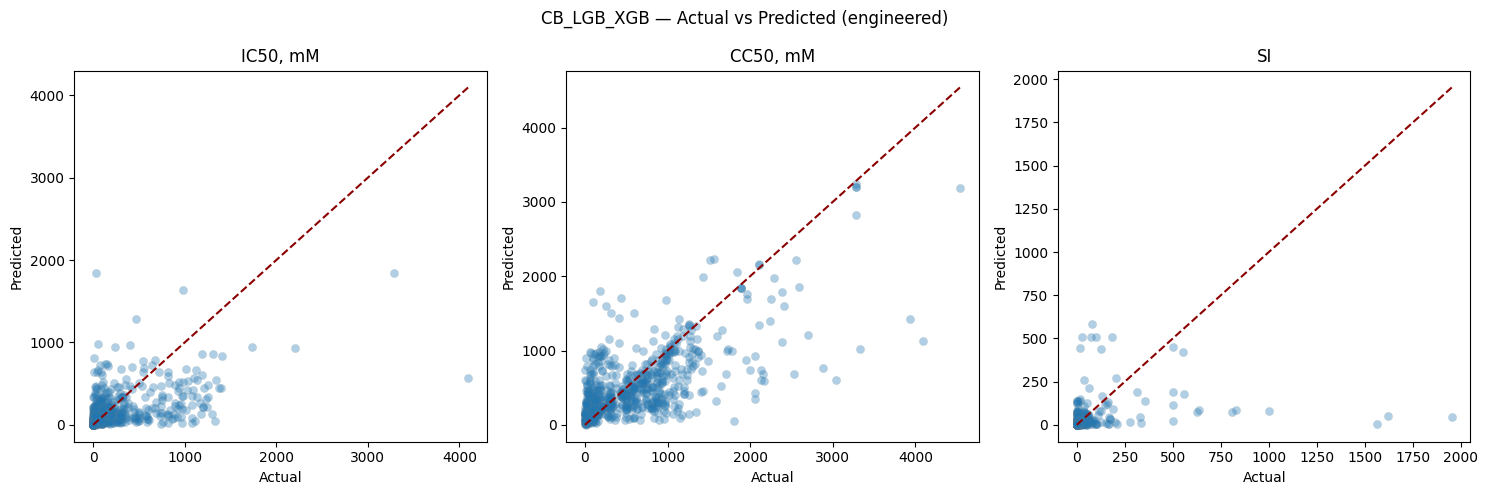

In [17]:
for config in ensemble_configs:
    name = config[0]
    models_fns = config[1:]
    weights = best_configs2[name][0]

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    OOF2 = np.zeros_like(Y_tr2)

    for ti, vi in kf.split(X_tr2):
        f_val = np.zeros((len(vi), 3))
        for t_idx in range(3):
            m_list = [fn().fit(X_tr2[ti], Y_tr2[ti, t_idx]) for fn in models_fns]
            f_val[:, t_idx] = sum(w * m.predict(X_tr2[vi]) for w, m in zip(weights, m_list))
        OOF2[vi] = f_val

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for j, target_name in enumerate(TARGETS_ORIG):
        pred = np.clip(OOF2[:, j], 0, None)**2
        ax[j].scatter(Y_orig2[:, j], pred, alpha=0.35, edgecolors='grey', linewidth=0.2)
        lo, hi = min(Y_orig2[:, j].min(), 0), Y_orig2[:, j].max()
        ax[j].plot([lo, hi], [lo, hi], '--', color='darkred')
        ax[j].set_xlabel('Actual')
        ax[j].set_ylabel('Predicted')
        ax[j].set_title(target_name)
    plt.suptitle(f'{name} — Actual vs Predicted (engineered)')
    plt.tight_layout()
    plt.show()

## График остатков (engineered)

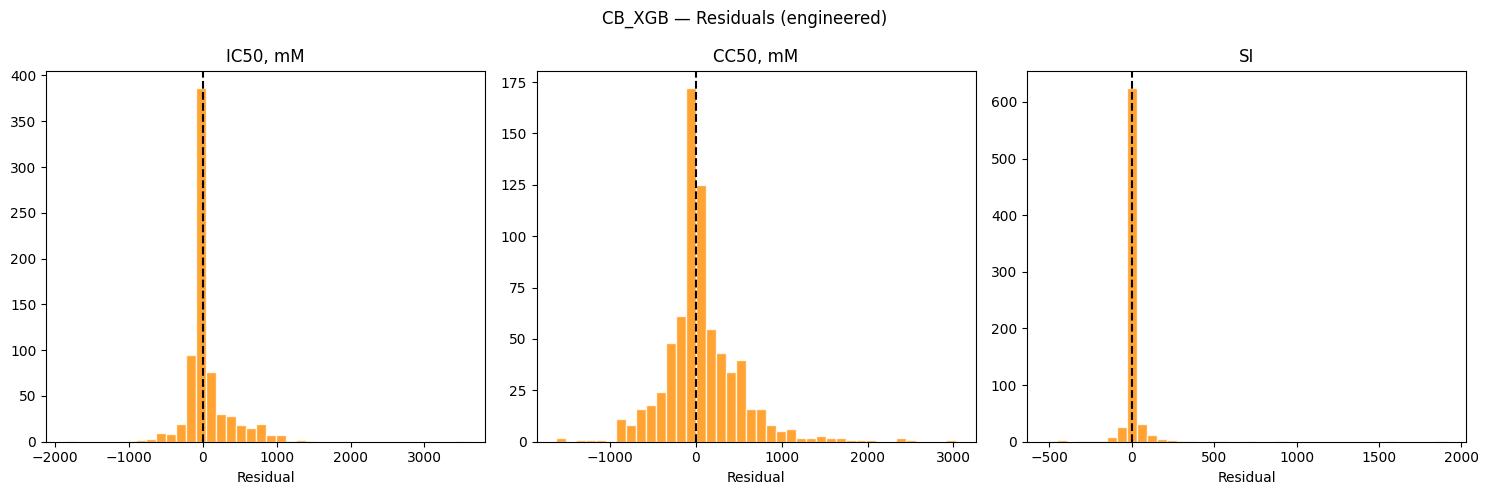

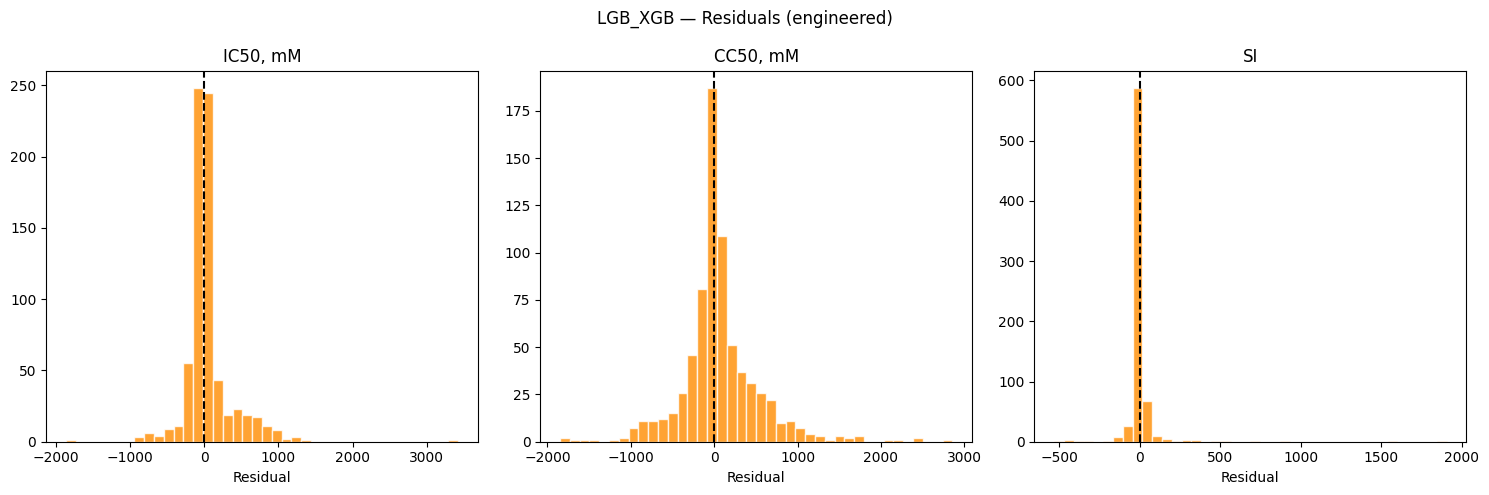

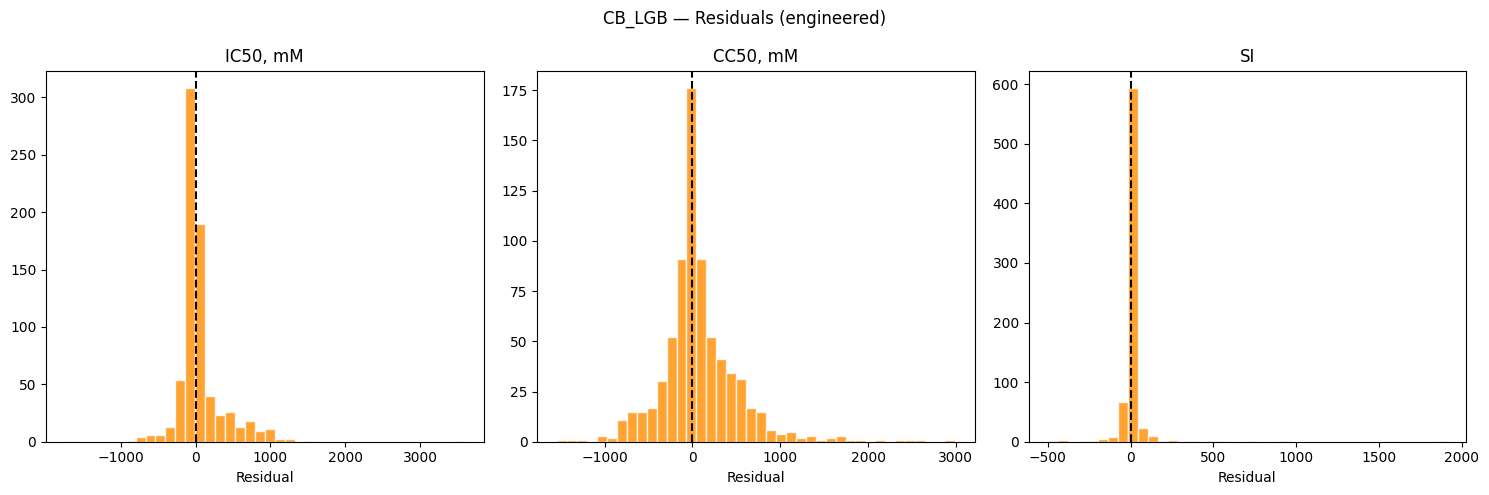

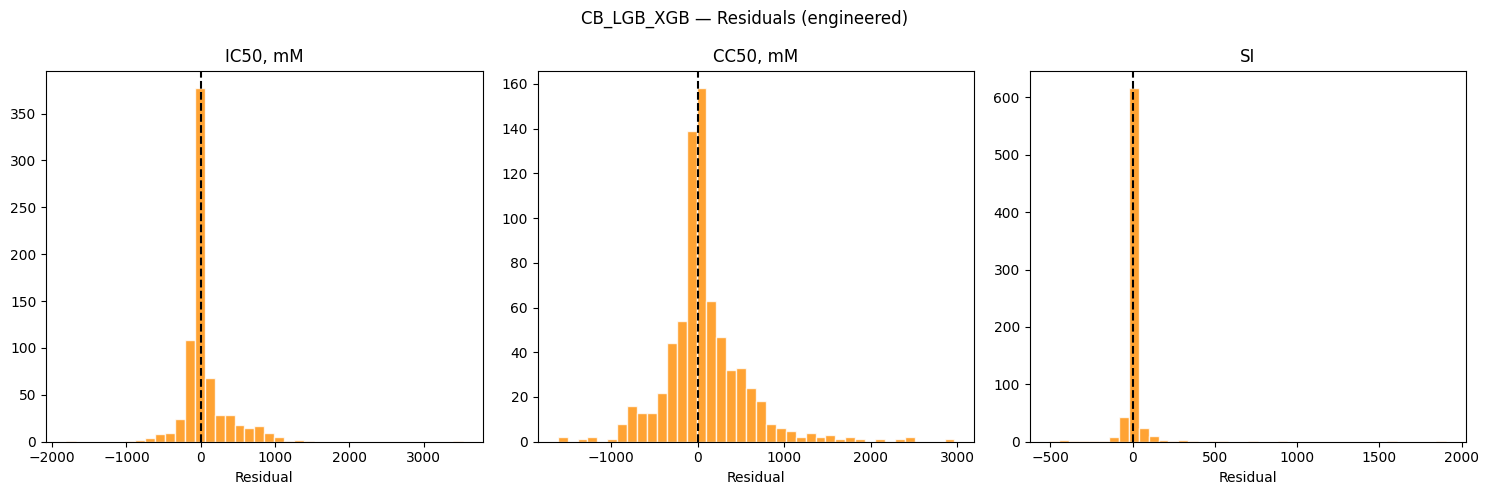

In [18]:
for config in ensemble_configs:
    name = config[0]
    models_fns = config[1:]
    weights = best_configs2[name][0]

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    OOF2 = np.zeros_like(Y_tr2)

    for ti, vi in kf.split(X_tr2):
        f_val = np.zeros((len(vi), 3))
        for t_idx in range(3):
            m_list = [fn().fit(X_tr2[ti], Y_tr2[ti, t_idx]) for fn in models_fns]
            f_val[:, t_idx] = sum(w * m.predict(X_tr2[vi]) for w, m in zip(weights, m_list))
        OOF2[vi] = f_val

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for j, target_name in enumerate(TARGETS_ORIG):
        res = Y_orig2[:, j] - np.clip(OOF2[:, j], 0, None)**2
        ax[j].hist(res, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
        ax[j].axvline(0, color='black', linestyle='--')
        ax[j].set_xlabel('Residual')
        ax[j].set_title(target_name)
    plt.suptitle(f'{name} — Residuals (engineered)')
    plt.tight_layout()
    plt.show()